# Task 5: Machine Learning Modeling

### Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

### Step 2: Load Dataset

In [2]:
df = pd.read_csv("titanic.csv")

In [3]:
column_list = df.columns.tolist()

print(column_list)

['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare']


In [4]:
# Display first 5 rows
print(df.head())

   Survived  Pclass                                               Name  \
0         0       3                             Mr. Owen Harris Braund   
1         1       1  Mrs. John Bradley (Florence Briggs Thayer) Cum...   
2         1       3                              Miss. Laina Heikkinen   
3         1       1        Mrs. Jacques Heath (Lily May Peel) Futrelle   
4         0       3                            Mr. William Henry Allen   

      Sex   Age  Siblings/Spouses Aboard  Parents/Children Aboard     Fare  
0    male  22.0                        1                        0   7.2500  
1  female  38.0                        1                        0  71.2833  
2  female  26.0                        0                        0   7.9250  
3  female  35.0                        1                        0  53.1000  
4    male  35.0                        0                        0   8.0500  


### Step 3: Understand Dataset

In [5]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(887, 8)


In [6]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard',
       'Parents/Children Aboard', 'Fare'],
      dtype='object')


In [7]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Name                     887 non-null    object 
 3   Sex                      887 non-null    object 
 4   Age                      887 non-null    float64
 5   Siblings/Spouses Aboard  887 non-null    int64  
 6   Parents/Children Aboard  887 non-null    int64  
 7   Fare                     887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB
None


In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64


### Step 4: Exploratory Data Analysis (EDA)

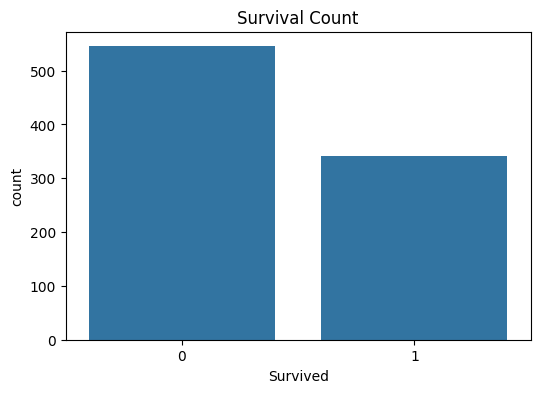

In [9]:
# SURVIVAL COUNT

plt.figure(figsize=(6,4))

sns.countplot(x='Survived', data=df)

plt.title("Survival Count")
plt.show()

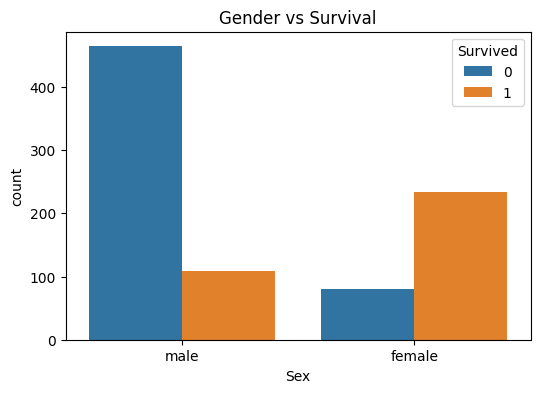

In [10]:
# GENDER VS SURVIVAL

plt.figure(figsize=(6,4))

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Gender vs Survival")
plt.show()

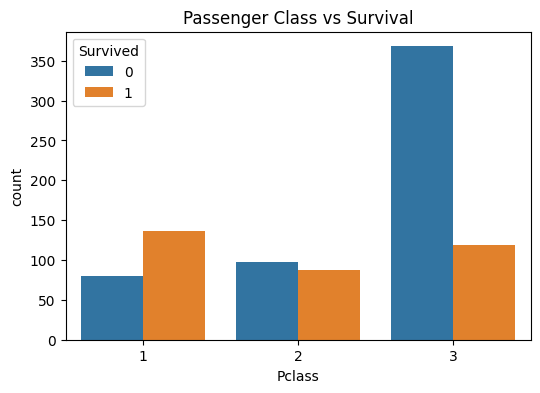

In [11]:
# Passenger CLASS VS SURVIVAL

plt.figure(figsize=(6,4))

sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title("Passenger Class vs Survival")
plt.show()

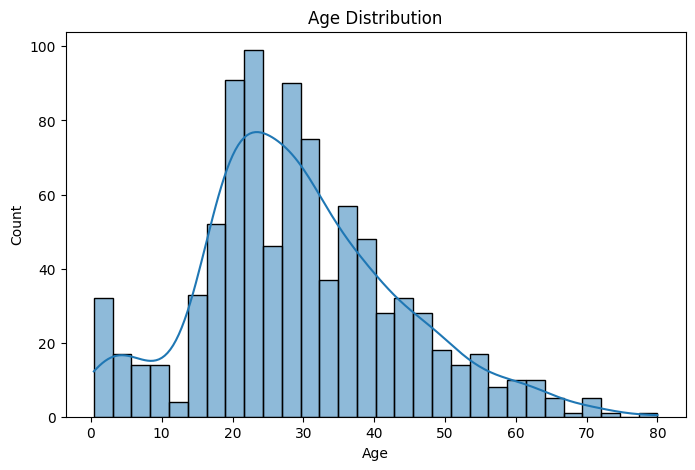

In [12]:
# AGE DISTRIBUTION

plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution")
plt.show()

### Step 5: Data Cleaning

In [13]:
# Fill missing Age values using median
df['Age'] = df['Age'].fillna(df['Age'].median())

### Step 6: Feature Engineering

In [14]:
# FEATURE ENGINEERING

df['FamilySize'] = (
    df['Siblings/Spouses Aboard'] +
    df['Parents/Children Aboard'] + 1
)

In [15]:
#Create IsAlone Feature
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [16]:
# Extract title from passenger name

df['Title'] = df['Name'].str.extract(r'([A-Za-z]+)\.')

### Step 7: Select Features

In [17]:
# SELECT FEATURES
features = [
    'Pclass',
    'Sex',
    'Age',
    'Fare',
    'FamilySize',
    'IsAlone',
    'Title'
]

X = df[features]

# Target column
y = df['Survived']

### Step 8: Separate Numerical & Categorical Columns

In [18]:
# CATEGORICAL & NUMERICAL COLUMNS
categorical_features = ['Sex', 'Title']

numerical_features = [
    'Pclass',
    'Age',
    'Fare',
    'FamilySize',
    'IsAlone'
]

### Step 9: Preprocessing Pipeline

In [19]:
# PREPROCESSING PIPELINE
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

### Step 10: Train Test Split

In [20]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (709, 7)
Testing Data Shape: (178, 7)


### Step 11: Create Machine Learning Models

In [21]:
# MACHINE LEARNING MODELS
models = {

    "Logistic Regression": Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ]),

    "Random Forest": Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ])
}

### Step 12: Train Models & Evaluate

In [22]:
# MODEL TRAINING & EVALUATION

results = {}

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    # Store results
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

    # Print Results
    print("\n=========================")
    print(name)
    print("=========================")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy : 0.8258
Precision: 0.7879
Recall   : 0.7536
F1-Score : 0.7704

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       109
           1       0.79      0.75      0.77        69

    accuracy                           0.83       178
   macro avg       0.82      0.81      0.82       178
weighted avg       0.82      0.83      0.83       178


Random Forest
Accuracy : 0.7584
Precision: 0.6857
Recall   : 0.6957
F1-Score : 0.6906

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       109
           1       0.69      0.70      0.69        69

    accuracy                           0.76       178
   macro avg       0.75      0.75      0.75       178
weighted avg       0.76      0.76      0.76       178



### Step 13: Compare Model Performance

In [23]:
# MODEL COMPARISON

results_df = pd.DataFrame(results).T

print(results_df)

                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.825843   0.787879  0.753623  0.770370
Random Forest        0.758427   0.685714  0.695652  0.690647


### Step 14: Visualization of Model Accuracy

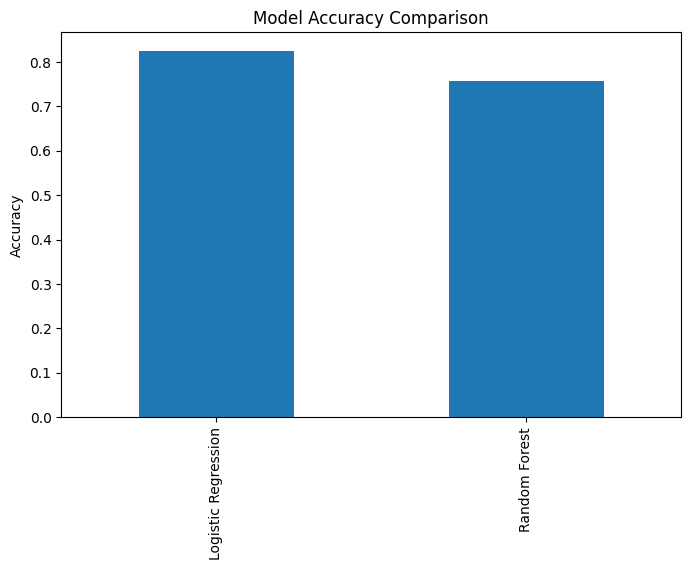

In [24]:
# MODEL ACCURACY GRAPH

results_df['Accuracy'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

### Step 15: Confusion Matrix

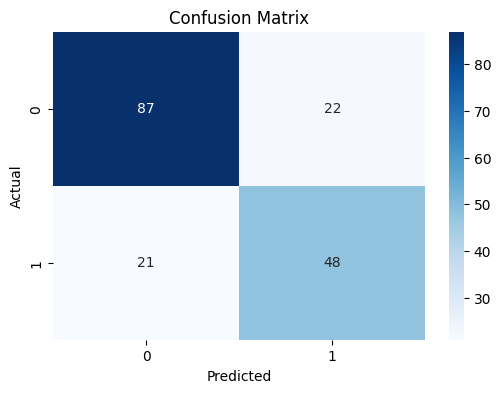

In [25]:
# CONFUSION MATRIX

best_model = models['Random Forest']

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### Step 16: Feature Importance

In [26]:
# FEATURE IMPORTANCE
rf_model = models['Random Forest']

# Get encoded categorical feature names
encoded_cat_features = list(
    rf_model.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)

# Combine all feature names
all_features = numerical_features + encoded_cat_features

# Importance scores
importances = (
    rf_model.named_steps['classifier']
    .feature_importances_
)

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
})

# Sort values
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

           Feature  Importance
2             Fare    0.276789
1              Age    0.247447
5       Sex_female    0.094707
6         Sex_male    0.084109
18        Title_Mr    0.080171
0           Pclass    0.078577
3       FamilySize    0.058854
19       Title_Mrs    0.022452
16      Title_Miss    0.019897
4          IsAlone    0.014795
15    Title_Master    0.011027
21       Title_Rev    0.002695
11        Title_Dr    0.001575
22       Title_Sir    0.001489
8        Title_Col    0.001449
14     Title_Major    0.001399
10       Title_Don    0.000747
7       Title_Capt    0.000682
17      Title_Mlle    0.000456
20        Title_Ms    0.000230
12  Title_Jonkheer    0.000172
13      Title_Lady    0.000166
9   Title_Countess    0.000115


### Step 17: Plot Feature Importance

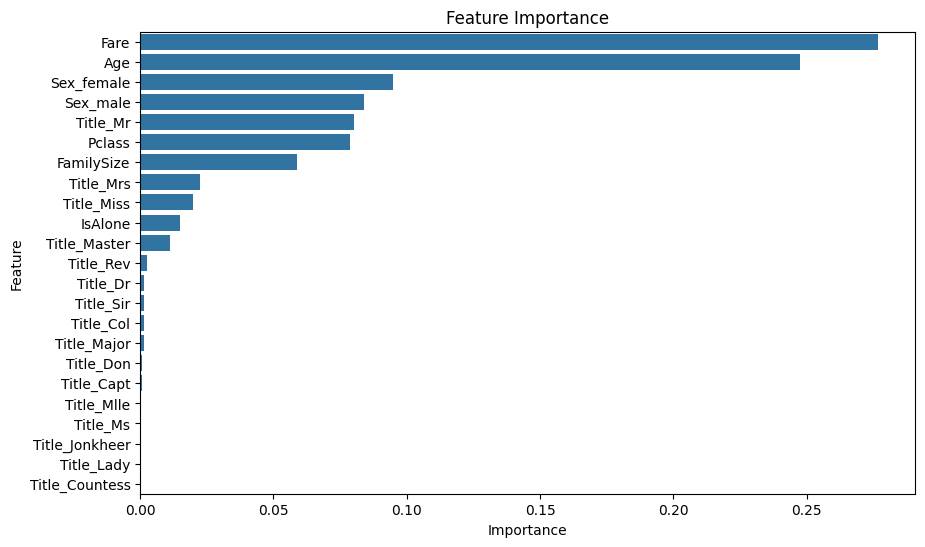

In [27]:
# FEATURE IMPORTANCE GRAPH
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("Feature Importance")

plt.show()

### Step 18: Final Business Insights

In [28]:
# FINAL INSIGHTS

print("\nKEY INSIGHTS")

print("""
1. Female passengers had higher survival rates.

2. First-class passengers survived more often.

3. Fare was an important survival factor.

4. Random Forest performed better than Logistic Regression.

5. Family-related features slightly improved predictions.
""")


KEY INSIGHTS

1. Female passengers had higher survival rates.

2. First-class passengers survived more often.

3. Fare was an important survival factor.

4. Random Forest performed better than Logistic Regression.

5. Family-related features slightly improved predictions.

